<a href="https://colab.research.google.com/github/Wezz-git/AI-samples/blob/main/(ARIMA)_Classical_Time_Series_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**The Focus:** Benchmark Forecasting and Statistical Foundation.

**The Project Aim:** To build the classical, statistical time-series model (ARIMA) for forecasting demand. This proves mastery over the fundamental statistical assumptions (like Stationarity) that underpin all modern forecasting.

**The Goal:** To prove why an advanced Machine Learning model (like your LSTM) is necessary, by contrasting its performance against the highly interpretable, established statistical benchmark.

Data Acquisition & Stationarity Check

--- Raw Monthly Time Series Plot ---


/tmp/ipython-input-2431810995.py:16: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(start='2000-01-01', periods=len(data_list), freq='M')
/tmp/ipython-input-2431810995.py:18: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df.index.freq = 'M' # Set frequency to Month


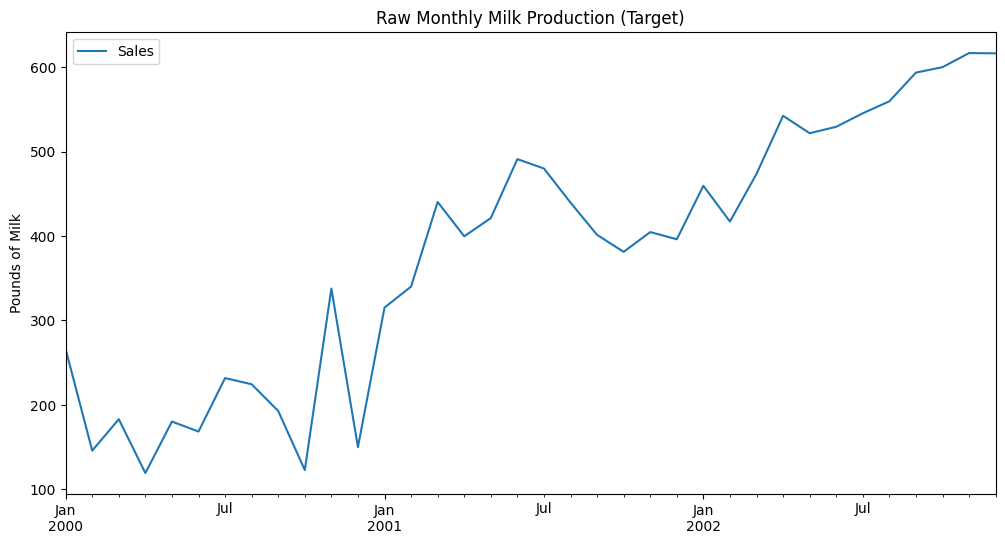

ADF Statistic: -0.3701
p-value: 0.9150


In [12]:
!pip install statsmodels

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

# Create a Clean, Reliable Time Series from local source
# Data list to guarantee a stable environment
data_list = [266.0, 145.9, 183.1, 119.3, 180.3, 168.5, 231.8, 224.5, 192.8, 122.9, 337.8, 150.0,
             315.3, 340.2, 440.4, 399.7, 421.3, 491.1, 480.0, 439.6, 401.4, 381.3, 404.7, 396.2,
             459.5, 417.2, 473.6, 542.4, 521.8, 529.4, 545.4, 559.6, 593.6, 600.0, 616.7, 616.4]

# Created a simple date range for the index
dates = pd.date_range(start='2000-01-01', periods=len(data_list), freq='M')
df = pd.DataFrame({'Sales': data_list}, index=dates)
df.index.freq = 'M' # Set frequency to Month

# Plot Raw Time-Series
print("--- Raw Monthly Time Series Plot ---")
df.plot(figsize=(12, 6))
plt.title('Raw Monthly Milk Production (Target)')
plt.ylabel('Pounds of Milk')
plt.show()

# Run ADF test (Statistical check for non-stationarity)
result = adfuller(df['Sales'])
p_value = result[1]
print(f'ADF Statistic: {result[0]:.4f}')
print(f'p-value: {result[1]:.4f}')

# Conclusion: If p-value is > 0.05, the data is NOT stationary.

The rule for the ADF test:

Null Hypothesis (H₀): The time series is NOT stationary (it has a trend/pattern).

Decision Rule: If the p-value is greater than 0.05, we fail to reject H₀.

Make the Data Stationary (Differencing)

--- Differenced Series Plot ---


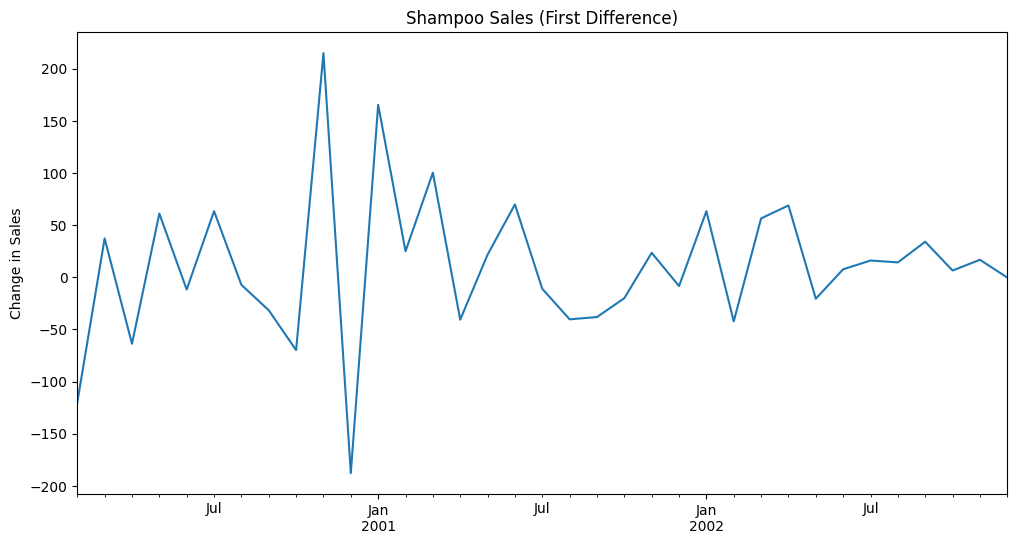


--- ADF Test on First Difference ---
ADF Statistic: -11.5151
p-value: 0.0000


In [13]:
# Create a First_Diff col
# Apply First Differencing
# Subtract the sales from the previous period (periods=1 is the default)

df['First_Diff'] = df['Sales'].diff()

# Drop the first row (which is NaN after differencing)
df_diff = df['First_Diff'].dropna()

# Plot the Differenced Series
print("--- Differenced Series Plot ---")
df_diff.plot(figsize=(12, 6))
plt.title('Shampoo Sales (First Difference)')
plt.ylabel('Change in Sales')
plt.show()

# Run the ADF Test on the new column
print("\n--- ADF Test on First Difference ---")
result_diff = adfuller(df_diff)
print(f'ADF Statistic: {result_diff[0]:.4f}')
print(f'p-value: {result_diff[1]:.4f}')

ADF Statistic: -11.5151 (The more negative, the better)

p-value: 0.0000 (Statistically zero)

The p-value for the differenced data is 0.0000 (much less than 0.05).

Determining ARIMA Parameters (p, d, q)

d (Integrated): The Differencing order. Since applying the First Difference once, $d = 1$. (If the p-value was still high, try a second difference, making $d=2$).

p (Autoregressive): Measures how many past lags of the time series itself influence the current value.

q (Moving Average): Measures how many past lags of the error (white noise) influence the current value.

find p and q by looking at two specific plots: ACF (Autocorrelation Function) and PACF (Partial Autocorrelation Function).

<Figure size 1200x600 with 0 Axes>

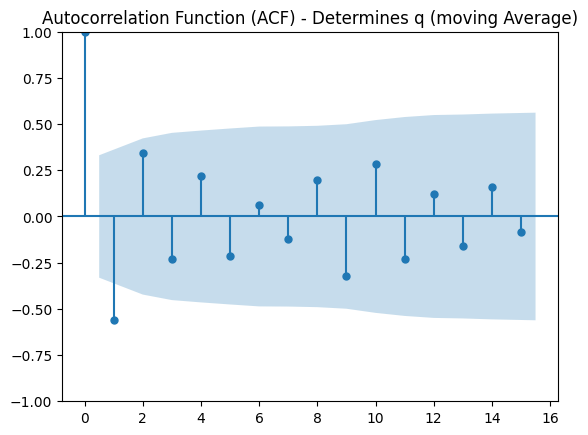

<Figure size 1200x600 with 0 Axes>

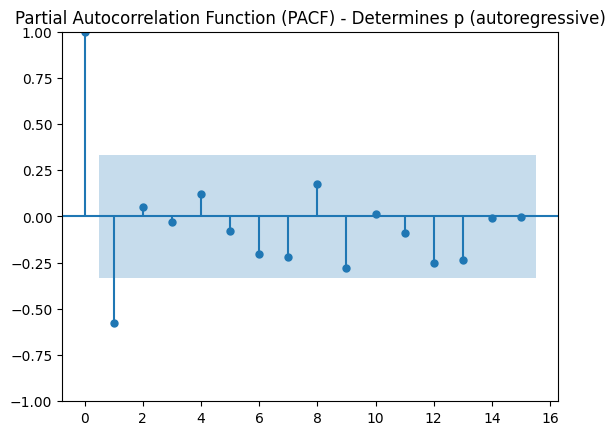

In [14]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Define stationary data (first difference)
df_stationary = df['First_Diff'].dropna()

# Plot Autocorrelation function (ACF)
# ACF determines the 'q' parameter
plt.figure(figsize=(12, 6))
plot_acf(df_stationary, lags=15)
plt.title('Autocorrelation Function (ACF) - Determines q (moving Average)')
plt.ylim(-1, 1)
plt.savefig('Autocorrelation Function (ACF) - Determines q (moving Average.png')

# Plot Partial Autocorrelation Function (PACF)
# PACF determines 'p' parameter
plt.figure(figsize=(12, 6))
plot_pacf(df_stationary, lags=15, method='yw')     # 'yw' method is standard for stationary data
plt.title('Partial Autocorrelation Function (PACF) - Determines p (autoregressive)')
plt.ylim(-1, 1)
plt.savefig('Partial Autocorrelation Function (PACF) - Determines p (autoregressive).png')

Build and Forecast with Arima Model

Training ARIMA model...


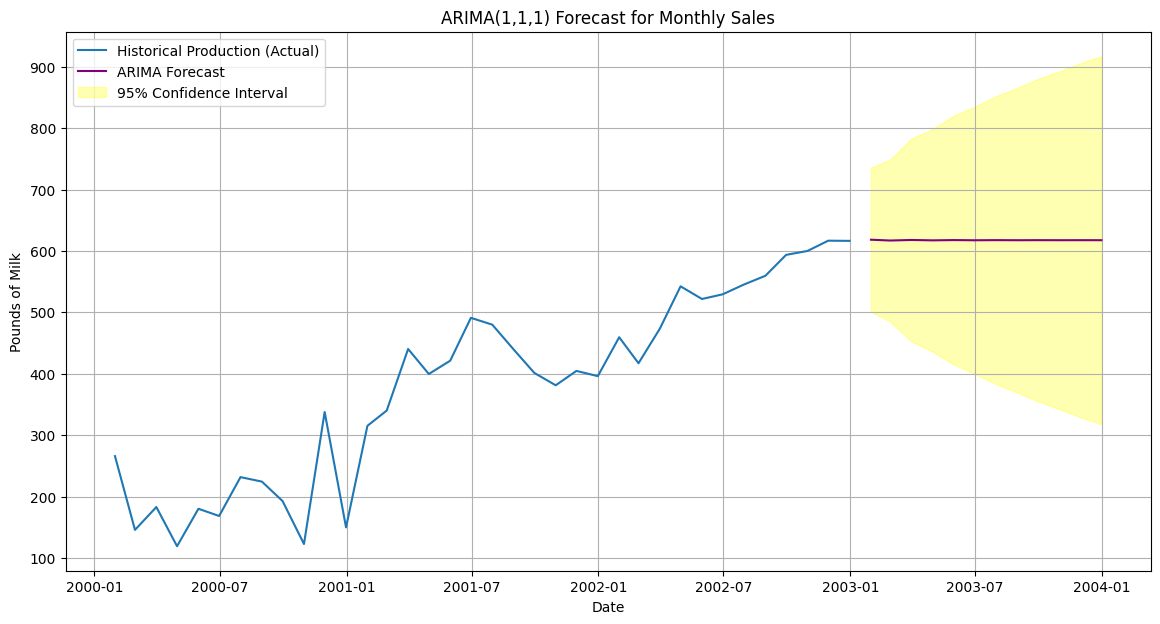

In [17]:
from statsmodels.tsa.arima.model import ARIMA

# Define stationary data
df_stationary = df['First_Diff'].dropna()

# Define training data
train = df['Sales']

# Build and fit ARIMA model
# order = (1, 1, 1) -> p=1, d=1, q=1
model = ARIMA(train, order=(1, 1, 1))

print("Training ARIMA model...")
results = model.fit()

# Genarate forecast. Forecast for 12 steps (months) ahead
forecast_steps = 12
forecast = results.get_forecast(steps=forecast_steps)

# Extract predictions mean and confidence intervals
forecast_mean = forecast.predicted_mean
forecast_ci = forecast.conf_int()

# Plot the results
plt.figure(figsize=(14, 7))
plt.plot(train.index, train, label='Historical Production (Actual)')
plt.plot(forecast_mean.index, forecast_mean, label='ARIMA Forecast', color='purple')

# Plot 95% confidence interval (area of uncertainty)
plt.fill_between(forecast_ci.index, forecast_ci.iloc[:, 0], forecast_ci.iloc[:, 1],
                 color='yellow', alpha=0.3, label='95% Confidence Interval')

plt.title('ARIMA(1,1,1) Forecast for Monthly Sales')
plt.xlabel('Date')
plt.ylabel('Pounds of Milk')
plt.legend()
plt.grid(True)
plt.savefig('ARIMA(1,1,1) Forecast for Monthly Sales.png')